In [1]:
import classical_2D as main
import quantum_2D as quant

import sys
sys.path.append("../funcs")

import geometry as geo
import kernals as ker
import metrics as met

import numpy as np
import matplotlib.pyplot as plt


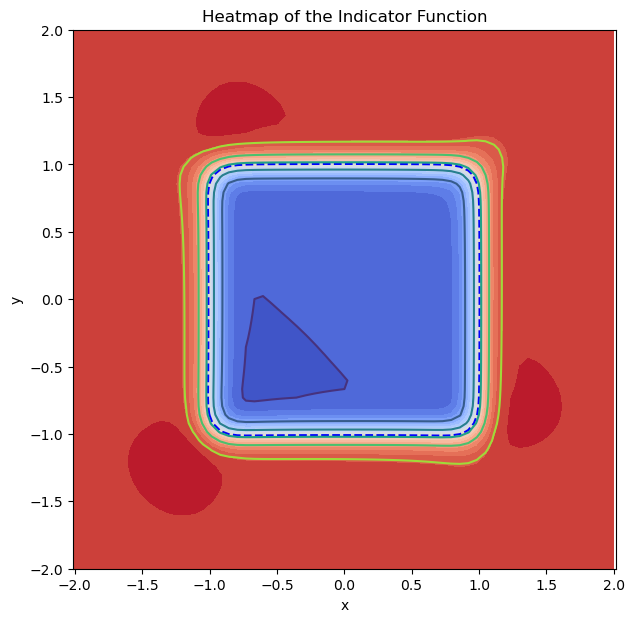

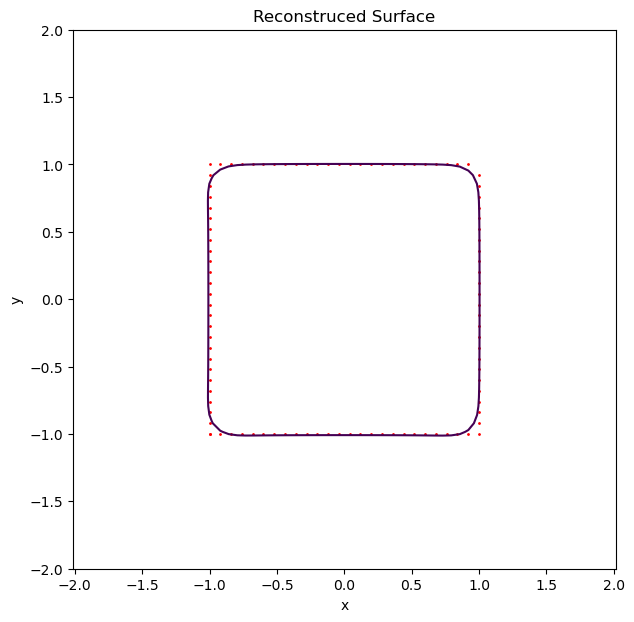

0.9814552270366607


In [ ]:

size = 2

nx = 64
ny = 64

x = np.linspace(-size, size, nx)
y = np.linspace(-size, size, ny)

X, Y = np.meshgrid(x, y, indexing="ij")

scan_points, scan_normals = geo.generate_square_points()

chi_grid, iso_value = main.surface_reconstruction(scan_points, scan_normals, size, nx, ny, ker.gaussian, sigma=0.1)


plt.figure(figsize=(7, 7))

plt.contour(
    X,
    Y,
    chi_grid,
    levels=[iso_value],
    colors="blue"
)

plt.contourf(X, Y, chi_grid, cmap="coolwarm", levels=20)
plt.contour(X, Y, chi_grid)

plt.axis("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Heatmap of the Indicator Function")
plt.show()


fig, ax = plt.subplots(figsize=(7, 7))

contour = ax.contour(
    X,
    Y,
    chi_grid,
    levels=[iso_value]
)

ax.scatter(
    scan_points[:, 0],
    scan_points[:, 1],
    color="red",
    s=1,
    zorder=1
)

plt.axis("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Reconstruced Surface")
plt.show()


iou = met.square_vs_isosurface_iou(chi_grid, iso_value, x, y)
print(iou)


num =   8, IoU = 0.826879
num =  16, IoU = 0.935251
num =  32, IoU = 0.973180
num =  64, IoU = 0.981455
num = 128, IoU = 0.983404


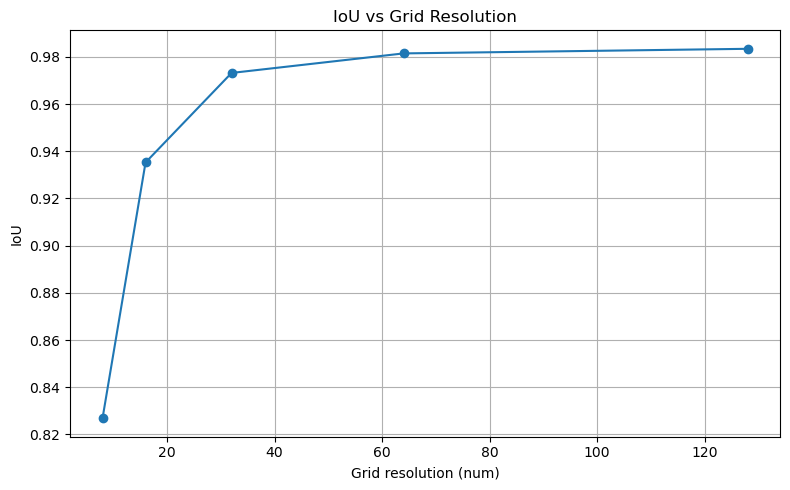

In [ ]:

import numpy as np
import matplotlib.pyplot as plt


size = 2

num_values = [8, 16, 32, 64, 128]

iou_values = []


for num in num_values:

    nx = num
    ny = num
    
    x = np.linspace(-size, size, nx)
    y = np.linspace(-size, size, ny)
    
    X, Y = np.meshgrid(x, y, indexing="ij")

    chi_grid, iso_value = main.surface_reconstruction(scan_points, scan_normals, size, nx, ny, ker.gaussian, sigma=0.1)

    iou = met.square_vs_isosurface_iou(chi_grid, iso_value, x, y)

    iou_values.append(iou)

    print(
        f"num = {num:3d}, IoU = {iou:.6f}"
    )


plt.figure(figsize=(8, 5))

plt.plot(
    num_values,
    iou_values,
    marker="o"
)

plt.xlabel("Grid resolution (num)")
plt.ylabel("IoU")
plt.title("IoU vs Grid Resolution")

plt.grid(True)

plt.tight_layout()
plt.show()